# Georg-August-Universität Göttingen - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Georg-August-Universität Göttingen' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              142 -- 'Georg-August-Universität Göttingen'
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Georg-August-Universität Göttingen,"Chair for Economic Policy and SME Research, Ge...",https://openalex.org/W4285256206
1,not assigned,Georg-August-Universität Göttingen,"Retail Logistics Lab, Department of Business A...",https://openalex.org/W4308868305
2,not assigned,Georg-August-Universität Göttingen,"Department of Medical Informatics, University ...",https://openalex.org/W4224869355
3,not assigned,Georg-August-Universität Göttingen,Centre of Biodiversity and Sustainable Land Us...,https://openalex.org/W4224135651
4,not assigned,Georg-August-Universität Göttingen,Tropical Plant Production and Agricultural Sys...,https://openalex.org/W4224135651


In [29]:
MAPPING_DICT = {
    'Bernstein Zentrum für Computational Neuroscience Göttingen': ['computational neuroscience', 'bernstein zentrum'], # selbst ergänzt
    'Campus Institut für Dynamik biologischer Netzwerke (CIDBN)': ['biological networks'],
    'Campus-Institut Data Science (CIDAS)': ['cidas', 'campus(‐|\s)inst(.|itut(e)?) data science'],
    'Centre for Modern Indian Studies (CeMIS)': ['cent(er|re) for modern indian studies'],
    'Center for Integrated Breeding Research (CiBreed)': ['int\w* breeding', 'breeding research'], # selbst ergänzt
    'Courant Forschungszentrum Armut, Ungleichheit und Wachstum in Entwicklungsländern': ['poverty equity'],
    'Courant Forschungszentrum Bildung und Religion': ['bildung und religion'],
    #'Courant Forschungszentrum Evolution des Sozialverhaltens': [],
    #'Courant Forschungszentrum Nanospektroskopie und Röntgenbildgebung': [],
    #'Courant Forschungszentrum Geobiologie': [],
    #'Courant-Forschungszentrum Textstrukturen': [],
    #'DFG Forschungszentrum für Molekularphysiologie des Gehirns': [],
    #'Erasmus Mundus Programme Euroculture - Society, politics and culture in a global context': [],
    'Fakultät für Agrarwissenschaften': ['landwirtschaftlich', 'agricultural(?!(\ssoil|\suniversity|\slaw))', 'veterinary', 'crop (science|plant|production)', 
                                         'mycotoxin', 'soil hydrology', 'nutzpflanzen', 'faculty of agriculture', 'agrosystems modelling',
                                         'agro(ecology|biodiversity|nomy)', 'biogeochemistry', 'plant (pathology|breeding|nutrition|products)', 
                                         'animal (medicine|hygiene|breeding|science|plant)', 'husbandry', 'agrarökonomie', 'grassland', 
                                         'tierärztliches institut', 'agrarökosysteme',
                                        ],
    'Fakultät für Biologie und Psychologie': ['biolog(ie|y) (and|und|&) psycholog(ie|y)', 'blumenbach', 'evolution of plants', 'georg-elias', 'conservation biology',
                                              '(department|institute) of psychology', '(animal|human|behavioral) ecology', 'climate dynamics', 'applied bioinformatics',
                                              'cent(er|re) (of|for) molecular biosciences', 'von(-|‐|\s)haller', 'plant cell biology', 'zoolog(ie|y) (und|and) anthropolog(ie|y)',
                                              'enzymology', '(educational|developmental|experimental) psychology', 'plant ecology', 'zelluläre neurobiologie',
                                              'mi(k|c)robiolog(ie|y) (und|and|&amp;) geneti(k|cs)', 'behavioural biology', 'plant biochemistry',
                                              '(so(z|c)io|neuro)biolog(ie|y)', 'psychologie und psychotherapie', 'molecular structural biology', 'biology education',
                                              'psychology of language', 'phycology', '(general|applied) microbiology', 'developmental biology',
                                              'vegetation', '(abteilung|animal) evolution', '(?<!integrative\s)(?<!auditory\s)genomic', 
                                              ' social and communication', 'institute for microbiology',
                                              'evolutionary developmental', 'zentrum für molekulare biowissenschaften', 'department of bioinformatics'
                                             ],
    'Fakultät für Chemie': ['(physi(kalische|cal)|(an|in)organi(sche|c)) chemi(e|st(r)?y)', 'bi(o)?mole(k|c)ular', '(faculty|department) of chemistry', 'w(ö|oe)hler',
                            'organic chemistry', 'fakultät für chemie'
                           ],
    'Fakultät für Forstwissenschaften und Waldökologie': ['centre of biodiversity', 'forest', 'wood', 'biogeography', 'ecosystem modelling',
                                                          'radio(‐|-)?isotopes', '(soil|wildlife) science', 'stable isotope', 'bioclimatology',
                                                          'wildlife', 'forstwissenschaften', 'conservation policy', 'forstgenetik', 'silviculture',
                                                          'waldökologie'
                                                         ],
    'Fakultät für Geowissenschaften und Geographie': ['geo(dynamics|science)', 'mineralog(ie|y)', 'geowissenschaftliches zentrum', 
                                                      '(physical|human|kristallo)(\s)?(geo)?graph(ie|y)', 'intitute of geography',
                                                      'sedimentolog(ie|y)', 'cartography', '(angewandte|applied|isotope(n)?)(\s)?geolog(ie|y)', 'geoscientific',
                                                      '(department|institute) of geo(biology|graphy)', 'abt(.|eilung) geochemie', 'geographisches',
                                                      'center for earth sciences', 'strukturgeologie', 'faculty of geology'
                                                     ],
    'Fakultät für Mathematik und Informatik': ['computer science', 'mathemati(k|cs|sch)', 'stochastic', 'bernstein‐institute', 'institut(e)? (für|of) informati(k|cs)',
                                               'maschinelles lernen', 'computer security', 'breeding informatics', 'math(ematical)? institut', 
                                               'scientific information analytics group'
                                              ],
    'Fakultät für Physik': ['geophysik', 'complex systems', 'friedrich-hund', 'x(‐|-)ray physics', 'physics—biophysics', 
                            '(institute|fa(k|c)ult(ät|y)|department) (der|für|of) physi(k|cs)', 'didaktik der physik',
                            'phys(.|ikalisches|ical|ics) institut', 'theoreti(sche|cal) physi(k|cs)', 'material(s)?(\s)?physi(k|cs)', '(astro|r(ö|o)ntgen)physi(k|cs)',
                            'physics education'
                           ],
    #'Forum für interdisziplinäre Religionsforschung (FiReF)': [],
    'Gesellschaft für wissenschaftliche Datenverarbeitung mbH Göttingen': ['gwdg', 'escience', 
                                                                           'gesellschaft (für|f&#x00FC;r) wissenschaftliche(,)? datenverarbeitung'
                                                                          ],
    #'Graduiertenschule für Geisteswissenschaften Göttingen (GSGG)': [],
    'Göttinger Graduiertenzentrum für Neurowissenschaften': ['center nanoscale microscopy', 'molecular biosciences', 'developmental biochemistry',
                                                             'neurosciences'
                                                            ], 
    #'Göttinger Graduiertenzentrum für Neurowissenschaften, Biophysik und Molekulare Biowissenschaften (GGNB)'
    #'Informationsverbund Dermatologischer Kliniken (IVDK)': [],
    #'Interdisziplinäres Zentrum für Nachhaltige Entwicklung': [],
    'Juristische Fakultät': ['(rechts|kriminal)wissenschaften', '(bio|medizin|jugendstraf|landwirtschafts|arbeits|europa|familien|staatskirchen|verwaltungs)recht', 
                             'faculty of law', '(labour|agricultural|roman|criminal|procedural|european) law', 'juristische fakultät', 'grundlagen des rechts'
                            ],
    'Lichtenberg-Kolleg': ['lichtenberg'],
    'Niedersächsische Staats- und Universitätsbibliothek': ['bibliothek', 'library', 'papendiek 14', 'sub göttingen'],
    'Philosophische Fakultät': ['arch(a)?eology', '(früh|neuere)(\s)?geschichte', 'english', '(?<!social\s)(?<!sozial)philo(soph(ie|y)|log(ie|y))', 
                                'sprachwissenschaft', '(iranian|(east )?asian|romance|persianate|american|islamic) studies', 
                                'protohistory', 'romance languages', 'musicol(ogy)?',
                                'cultural anthropology', 'faculty of humanities', '(early|regional|modern) history', 
                                '(althistorisches|skandinavisches|ostasiatisches|philosophisches) seminar',
                                'kulturanthropologie', 'romance department', 'ägyptologie', 'department of history', 'theolog(ie|y)'
                               ],
    #'Sonderforschungsbereich 1136': [],
    'Sozialwissenschaftliche Fakultät': ['(institut(e)?|faculty) (für|of) (so(z|c)i|political|methoden)', 'democracy (research|studies)',
                                         '(sport(s)?|political|educational) science', '(politik|sport|erziehungs)wissenschaft', 'erziehungswissensch',
                                         'sozialwissenschaftliche fakultät', 'department of social sciences', 'social science(s)? faculty'
                                        ],
    'Theologische Fakultät': ['theologische fakultät'],
    'Universitätsmedizin Göttingen (UMG)': ['univ(ersi(t)?((ä|a|ae)ts|y)|.)?(\s|\sof\s)?(med|hosp|klinik)', 'gyn(äk|ec)olog(ie|y)', 'dentistry', 'cardiovascular',
                                            'medical (university )?(cent(re|er)|school|clinic|science)?', 'neuroimmunology', 'cardiology', 'psychosomatic',
                                            'h((a)?e|ä)matolog(ie|y)', 'radiolog(ie|y)', 'neurolog(ie|y)', 'medical (bio)?informatics', 'pneumology', '(augen|kinder|frauen)klinik',
                                            'pharmacology', 'an((a)?e|ä)sthesiolog(ie|y)', 'bioimaging', 'psychiatry', 'psychoneuroscience', 'dental', 'anatomy',
                                            'heart cent(er|re)', '(palliativ|intensiv)medizin', 'cellular biophysics', 'medizinische statistik', 'nephrolog(ie|y)',
                                            'infektiologie', '(trauma|neuro|thoracic|neck)(\s)?surgery', 'epidemiology', 'medizin und psychotherapie',
                                            'otorhinolaryngology', 'maxillofacial', 'jugendpsychiatrie', 'molecular cell', 'gastroenterolog(ie|y)',
                                            'otolaryngology', '889', '1690', '1286', '(department|faculty) of medicine', 'dermatolog(ie|y)', 'infectious diseases',
                                            'nuclear medicine', 'orthop(a)?edics', '(gesichts|unfall|kinder)chirurgie', 'hno(\s|-)((uni)?klinik|göttingen)',
                                            'cellular biochemistry', 'forensisch', 'geriatri(e|cs)', 'frauenheilkunde', "children's hospital",
                                            'klinik für psychiatrie', 'neuropathology', 'p(a)?ed(r)?iat(r)?ic', 'clinical psychology', 'ophthalmol',
                                            'cardiovasc', 'molecular oncology', 'virology', 'sensory physiology', 'general (practice|surgery)',
                                            'human(\s)?geneti(k|cs)', 'rheumatolog(ie|y)', 'institute of pathology', 'radiotherapy', 'neurophysiolog(ie|y)',
                                            'medizinische fakultät', '(umg|uniklinik) göttingen', 'molekulare psychiatrie', 'synaptic physiology',
                                            'integrative genomics'
                                           ],
    'Wirtschaftswissenschaftliche Fakultät': ['econometrics', 'innovation', 'department (of|for) economics', 'economic (sciences|policy)', 'business and economics',
                                              'business (education|administration)', 'logistics', '(professur|chair) (für|of) (marketing|statisti(k|cs)|financ(e|ial))',
                                              'information(s|\s)(management|systems)', 'anwendungssysteme', 'application systems', 'sozialgeschichte',
                                              '(development|public) economics', 'rechnungslegung', 'wirtschaftspädagogik', 'management and control', 
                                              'information security', 'volkswirtschaftslehre', 'wirtschaftswissenschaftliche fakultät', 'fakultät für wirtschaftswissenschaften'
                                             ],
    #'Zentrale Kustodie': [],
    #'Zentrum für Antike und Orient': [],
    'Zentrum für Biodiversität und Nachhaltige Landnutzung': ['cent(er|re) (for|of) (biodivers(i|o)ty|sustainable)'],
    #'Zentrum für empirische Unterrichts- und Schulforschung (ZeUS)': [],
    #'Zentrum für Globale Migrationsstudien (CeMig)': [],
    'Zentrum für Statistik': ['zentrum für statistik'],
    'ZESS - Zentrale Einrichtung für Sprachen und Schlüsselqualifikationen': ['schl(ü|ue)sselqualifikationen']
    ## An-Institute
    #'Volkswirtschaftliches Institut für Mittelstand und Handwerk an der Universität Göttingen e.V.': ['small business economics']
}

In [30]:
with open('./mapping_tables_fak/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [31]:
df_with_inst = oal.copy()

In [32]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [33]:
df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [34]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Chair for Economic Policy and SME Research, Ge...",https://openalex.org/W4285256206
1,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Retail Logistics Lab, Department of Business A...",https://openalex.org/W4308868305
2,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Medical Informatics, University ...",https://openalex.org/W4224869355
3,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,Centre of Biodiversity and Sustainable Land Us...,https://openalex.org/W4224135651
4,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Tropical Plant Production and Agricultural Sys...,https://openalex.org/W4224135651
...,...,...,...,...
43427,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"University of Goettingen, Department of Econom...",https://openalex.org/W3199735867
43428,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,"Sustainable Materials and Chemistry, Dep. Wood...",https://openalex.org/W4319239952
43429,Fakultät für Chemie,Georg-August-Universität Göttingen,"Institute of Inorganic Chemistry, Georg-August...",https://openalex.org/W4319239952
43430,Fakultät für Chemie,Georg-August-Universität Göttingen,Institute of Organic and Biomolecular Chemistr...,https://openalex.org/W4319239952


In [35]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[80:100]

array(['University of Göttingen, Platz der Göttinger Sieben 3, 37073, Göttingen, Germany. Electronic address: helena.schirmacher@uni-goettingen.de',
       'University Goettingen', 'Georg-August-University Göttingen',
       'T obias Schottdorf, Georg-August-Universität Göttingen',
       'Georg-August-Universität Göttingen Deutschland',
       'Georg‐August University School of Science (GAUSS) University of Göttingen  37073 Göttingen Germany',
       '(University of Göttingen, Germany',
       'Universität Göttingen, 37073 Göttingen, Germany',
       'Georg-August-University',
       'Universitt der Bundeswehr Mnchen University of Goettingen Universitt der Bundeswehr Mnchen University of Bamberg',
       'Georg-August-Universität Göttingen / Universidad de Talca',
       'Georg-August-University Göttingen, Göttingen, Germany',
       'Universidade de Gottingen/Gottingen, Alemanha',
       'IPB University and Georg-August-Universität Göttingen',
       'University of Goettingen, DNTW F

In [36]:
# check affiliated hosp
df_with_inst[df_with_inst.raw_affiliation_string.str.contains('affiliated')]

,fak_name,parent_name,raw_affiliation_string,openalex_id
2307,None,Georg-August-Universität Göttingen,"Independent scholar, Formerly affiliated with ...",https://openalex.org/W4405953300


In [37]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Bernstein Zentrum für Computational Neuroscien...,126
1,Campus Institut für Dynamik biologischer Netzw...,85
2,Campus-Institut Data Science (CIDAS),367
3,Center for Integrated Breeding Research (CiBreed),345
4,Centre for Modern Indian Studies (CeMIS),271
5,Courant Forschungszentrum Bildung und Religion,1
6,Fakultät für Agrarwissenschaften,3289
7,Fakultät für Biologie und Psychologie,3954
8,Fakultät für Chemie,2111
9,Fakultät für Forstwissenschaften und Waldökologie,3517


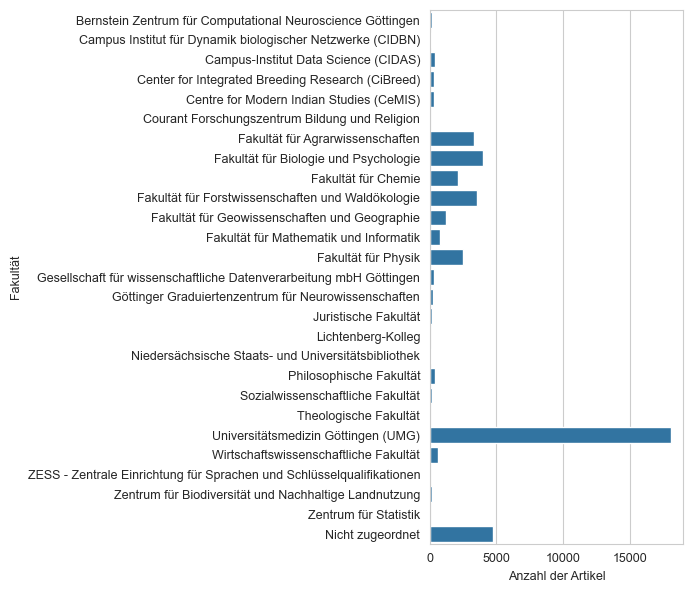

In [38]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [39]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.891715785595874

In [40]:
MAPPING_DICT_DEPT = {
    'Fakultät für Agrarwissenschaften': {
        #'Außenstelle Vechta': [],
        'Department für Agrarökonomie und Rurale Entwicklung': ['(agricultural|rural) economics', 'agricultural system', 'agrarökonomie', 'rural development'],
        'Department für Nutzpflanzenwissenschaften': ['crop (science|plant)', 'agroecosystems', 'biogeochemi(e|stry)', 'agro(ecology|biodiversity)', 'entomology', 
                                                      'phytopathology', 'plant breeding', 'pathology', 'grassland', 'agronomy', '(plant|agricultural) products',
                                                      'sensory and consumer', 'crop protection'
                                                     ],
        'Department Nutztierwissenschaften': ['animal (science|husbandry|medicine|hygiene)', 'veterinary medicine', 'nutztiere', 'tierärztliches',]
        #'Institut für angewandte Pflanzenernährung (IAPN)': []
    },
    'Fakultät für Biologie und Psychologie': {
        'Albrecht-von-Haller-Institut für Pflanzenwissenschaften': ['von(-|‐|\s)haller', 'bio(diversit(ät|y)|chemistry)', 'climate dynamics', 'plant ecology',
                                                                    'phycology', 'vegetation', 'molecular enzymology', 'plant cell'
                                                                   ],
        'Georg-Elias-Müller-Institut für Psychologie': ['georg(-|‐|\s)elias', '(department|institute) of psychology', 
                                                        '(developmental|educational|experimental|communication) psychology', 
                                                        'psychotherap(ie|y)', 'psychology of language'],
        'Institut für Mikrobiologie und Genetik': ['microbiology', 'molecular biosciences', 'microscopy', 'molekulare genetik', 'mikrobiologie',
                                                   'biowissenschaften', 'bioinformatics', 'structural biology'
                                                  ],
        'Johann-Friedrich-Blumenbach Institut für Zoologie und Anthropologie': ['blu(e)?menbach', 'sociobiology', 'anthropology', 
                                                                                '(developmental|conservation|multiscale) (biology|genetics)', 'abteilung evolution',
                                                                                'behavioral', 'animal ecology', 'neurobiolog(ie|y)'
                                                                               ]
    },
    'Fakultät für Chemie': {
        'Institut für Anorganische Chemie': ['(an)?organische chemie', '(in)?organic chemist(r)?y', 'chemistry education'],
        'Institut für Physikalische Chemie': ['(physikalische|biomolekular(e)?) chemie', '(physical|biomolecular) chemistry'],
        'Friedrich-Wöhler-Forschungsinstitut für Nachhaltige Chemie': ['w(ö|oe)hler(-|‐|\s)(research|(forschungs)?institut)']
    },
    'Fakultät für Forstwissenschaften und Waldökologie': {
        'Abteilung Landschaftshydrologie': ['hydrolog(ie|y)'],
        'Burckhardt-Institut': ['wood (biology|technology)', 'silviculture', '(nature|forest) conservation', 'remote sensing', 'conservation policy',
                                'naturschutzpolitik'
                               ],
        'Büsgen-Institut': ['(soil|wildlife) (science|biology)', 'cent(er|re) of biodiversity', 'biogeograph(ie|y)', 'tree (breeding|physiology)', 
                            'spatial structure', 'forstgenetik', 'forest work',
                            'sustainable\sland', 'bioclimatology', 'büsgen-institute', 'isotope research', 'radio(‐|-)?isotopes', 'ecosystem modelling',
                            'biometrics', 'wood biotechnology',
                           ],
    },
    'Fakultät für Geowissenschaften und Geographie': {
        'Geographisches Institut': ['(physical|human) geography', 'cartography', 'geographisches institut', 'institute of geography'],
        'Geowissenschaftliches Zentrum (GZG)': ['(applied|structural) geo(logy|science)', 'geochemi(e|stry)', 'geo(science(s)?|scientific) cent(er|re)', 
                                                'geowissenschaftliches zentrum', 'centre of geosciences', 'isotope geology',
                                                'computational', 'angewandte geologie', 'sediment', 'mineralog(ie|y)', 'geobiology'
                                               ]
    },
    'Fakultät für Mathematik und Informatik': {
        #'CRC - Courant Forschungszentrum "Strukturen höherer Ordnung"': [],
        'Institut für Informatik (IfI)': []
    },
    'Fakultät für Physik': {
        'Arbeitsgruppe Didaktik der Physik': ['physics education', 'dida(k|c)ti(k|c)'],
        'I. Physikalisches Institut': ['(?<!i)i\.', '(first|1st|(?<!i)i)(\sphysical)? institute', '(erstes|(?<!i)i)(\sphysikalisches)? institut'],
        'II. Physikalisches Institut': ['(?<!i)ii\.', '(second|2nd|(?<!i)ii)(\sphysical)? institute', '(zweites|(?<!i)ii)(\sphysikalisches)? institut'],
        'III. Physikalisches Institut': ['(?<!i)iii\.', '(t(\s)?hird|3rd|(?<!i)iii)(\sphysical)? institute', '(drittes|(?<!i)iii)(\sphysikalisches)? institut'],
        'IV. Physikalisches Institut': ['iv\.', '(fourth|4th|iv)(\sphysical)? institute', '(viertes|iv)(\sphysikalisches)? institut', 'nanostructures'],
        'Institut für Astrophysik und Geophysik': ['astrophysi(k|c)', 'geophysi(k|c)'],
        'Institut für Dynamik komplexer Systeme': ['complex (systems|fluids)', 'komplexer systeme'],
        'Institut für Materialphysik': ['material(s)? physics', 'materia(l)?physik'],
        'Institut für Röntgenphysik': ['x(-|‐)ray', 'röntgenphysik'],
        'Institut für Theoretische Physik': ['theoreti(sche|cal)'],
    },
    'Juristische Fakultät': {
        'Institut für Arbeitsrecht': ['arbeitsrecht', 'labour law'],
        'Institut für Grundlagen des Rechts': ['social philosophy', 'sozialphilosophie'],
        'Institut für Kriminalwissenschaften': ['kriminalwissenschaften', 'kriminologie', 'landwirtschaftsrecht', 'strafrechtliches medizin', 
                                                '(criminal|agricultural) law'],
        'Institut für Privat- und Prozessrecht': ['medizinrecht', 'familienrecht'],
        'Institut für Völkerrecht und Europarecht': ['europarecht'],
        #'Institut für Wirtschaftsrecht': [],
        'Institut für Öffentliches Recht': ['öffentliches recht']
    },
    'Philosophische Fakultät': {
        'Althistorisches Seminar': ['althistorisches seminar'],
        'Archäologisches Institut und Sammlung der Gipsabgüsse': ['historic(al)? arch(a)?eology'],
        #'Christliche Archäologie und Byzantinische Kunstgeschichte': [],
        #'Diplomatischer Apparat': [],
        #'Finnisch-Ugrisches Seminar': [],
        #'Institut für Digital Humanities': [],
        'Institut für Historische Landesforschung': ['regional history'],
        'Institut für Kulturanthropologie/Europäische Ethnologie': ['anthropology'],
        #'Institut für Religionswissenschaft': [],
        #'Kunstgeschichtliches Seminar und Kunstsammlung': [],
        #'Moritz-Stern-Institut': [],
        'Musikwissenschaftliches Seminar': ['musicology'],
        'Ostasiatisches Seminar': ['asian studies'],
        'Philosophisches Seminar': ['philosophisches seminar', 'institut(e)? of philosophy'],
        #'Seminar für Altorientalistik': [],
        'Seminar für Arabistik / Islamwissenschaft': ['islamic studies'],
        'Seminar für Deutsche Philologie': ['german philology', 'deutsche philologie'],
        'Seminar für Englische Philologie': ['english (philology|linguistics|studies)', '(englische|klassische|classical) philolog(ie|y)', 'english department', 
                                             'iranian studies', 'department of english'
                                            ],
        'Seminar für Mittlere und Neuere Geschichte': ['(neuere|frühere) geschichte', 'skandinavisches seminar', 'frühgeschichte', 'romance (studies|languages)',
                                                       '(romanische|slavi(sche|c)) philolog(ie|y)', 'sprachwissenschaft', 'early history'],
        'Zentrum für Mittelalter- und Frühneuzeitforschung': ['modern history', 'protohistory', 'frühneuzeitforschung'],
        #'Sonderforschungsbereich 1136': [],
    },
    'Sozialwissenschaftliche Fakultät': {
        'Institut für Demokratieforschung': ['demokratieforschung', 'democracy (studies|research)'],
        'Institut für Diversitätsforschung': ['diversity research'],
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'educational science', 'center of methods'],
        'Institut für Politikwissenschaft': ['politikwissenschaft', 'political science'],
        'Institut für Soziologie': ['institut für soziologie', 'institute of sociology'],
        'Institut für Sportwissenschaften': ['sportwissenschaften', 'sport(s)? science'],
        'Koordinationsstelle Geschlechterforschung': ['gender studies']
    },
    'Theologische Fakultät': {
        'Institut für Spezialforschungen': ['lehrstuhl für kirchengeschichte', 'church history'],
        'Vereinigte Theologische Seminare': ['religionspädagogik', 'alttestamentliches seminar', 
                                             'systematischen theologie', 'religious education'],
    },
    'Universitätsmedizin Göttingen (UMG)': {
        'Abteilung Experimentelle Neurodegeneration': ['neurodegeneration', ' neurodegenerative'],
        'Abteilung für Geriatrie': ['geriatri(e|cs)'],
        'Abteilung Nuklearmedizin': ['nuclear medicine', 'nuklearmedizin'],
        'Abteilung Rechtsmedizin': ['rechtsmedizin', 'legal department'],
        'Abteilung Molekulare Onkologie': ['molecular oncology'], # selbst ergänzt
        'Center for Biostructural Imaging of Neurodegeneration (BIN)': ['biostructural'],
        #'Deutsches Zentrum für Kinder und Jugendgesundheit': [],
        'European Neuroscience Institute (ENI-G)': ['european neuroscience'],
        'Exzellenzcluster Multiscale Bioimaging': ['multiscale'],
        'Herzzentrum Göttingen': ['cardiology (and|&) pneumolo(g)?y', 'heart(\sresearch)? center', 'clinic for cardiology', 'herzzentrum', 
                                  'kardiologie und pneumologie'
                                 ],
        'Institut für Allgemeinmedizin': ['general practice', 'allgemeinmedizin'],
        'Institut für Arbeits-, Sozial- und Umweltmedizin': ['umweltmedizin'],
        'Institut für Auditorische Neurowissenschaften': ['auditory neuroscience', 'auditorische neurowissenschaften'],
        'Institut für Bioinformatik': ['bioinformatik'],
        'Institut für Diagnostische und Interventionelle Neuroradiologie': ['interventionelle radiologie', 'neuroradiolog(ie|y)'],
        'Institut für Ethik und Geschichte der Medizin': ['medical ethics', 'ethik und geschichte'],
        'Institut für Genetische Epidemiologie': ['epidemiolog(ie|y)'],
        'Institut für Humangenetik': ['human(\s)?genetics', 'humangenetik'],
        'Institut für Klinische Chemie': ['clinical chemistry', 'klinische chemie'],
        'Institut für Klinische Pharmakologie': ['clinical pharmacology'],
        'Institut für Klinische und Interventionelle Radiologie': ['interventional radiology', 'cardiac imaging'],
        'Institut für Kognitive Neurologie': ['cognitive neurology'],
        'Institut für Medizinische Bioinformatik': ['medical bioinformatics'],
        'Institut für Medizinische Informatik': ['medical informatics', 'medizinische informatik', 'medizininformatik'],
        'Institut für Medizinische Mikrobiologie': ['virolog(ie|y)', 'medical microbiology'],
        'Institut für Medizinische Psychologie und Medizinische Soziologie': ['medical sociology'],
        'Institut für Medizinische Statistik': ['medizinische statistik', 'medical statistics'],
        'Institut für Neuroimmunologie und Multiple-Sklerose-Forschung': ['neuroimmunologie', 'multiple sclerosis', 'sklerose'],
        'Institut für Neuropathologie': ['neuropatholog(ie|y)'],
        'Institut für Neurorehabilitationssysteme': ['neurorehabilitationssysteme'],
        'Institut für Pathologie': ['(institute|department) (for|of) pathology', 'institut für pathologie'],
        'Institut für Pharmakologie und Toxikologie': ['toxi(k|c)olog(ie|y)'],
        'Institut für Zelluläre und Molekulare Immunologie': ['molekulare immunologie', 'molecular immunology'],
        'Interdisziplinäre Notaufnahme (INA)': ['notaufnahme', 'emergency department'],
        'Klinik für Allgemein-, Viszeral- und Kinderchirurgie': ['kinderchirurgie', 'visceral', 'department of surgery'],
        'Klinik für Anästhesiologie': ['an(ä|e|ae)sthesiolog(ie|y)'],
        'Klinik für Augenheilkunde': ['augen(klinik|heilkunde)', '(clinic|department) of ophthalmology', 'eye center'],
        'Klinik für Dermatologie, Venerologie und Allergologie': ['dermatolog(ie|y)'],
        'Klinik für Gastroenterologie und gastrointestinale Onkologie': ['gast(e)?roenterolog(ie|y)'],
        'Klinik für Geburtshilfe und Gynäkologie': ['gynecology', 'gynäkologie'],
        'Klinik für Hals-Nasen-Ohrenheilkunde': ['hno(\s|-)(klinik|göttingen|heilkunde)', 'hals(-|-)nasen(-|-)ohren(klinik|heilkunde)', 
                                                 'otorhinolaryngology', 'otolaryngology', 'ohrenheilkunde'
                                                ],
        'Klinik für Hämatologie und Medizinische Onkologie': ['klinik für hämatologie', '(department|clinic(s)?) of hematology', 
                                                              'medical (h(a)?ematology|oncology)', 'medizinische onkologie'
                                                             ],
        'Klinik für Kinder- und Jugendmedizin': ['university children', 'adolescent (medicine|health)', 'pediatric hematology', 'klinik für kinder'],
        'Klinik für Kinder- und Jugendpsychiatrie und Psychotherapie': ['neurophysiology', 'adolescent psychiatry'],
        'Klinik für Klinische Neurophysiologie': ['klinische neurophysiologie'],
        'Klinik für Nephrologie und Rheumatologie': ['rheumatology', 'nephrolog(ie|y)'],
        'Klinik für Neurochirurgie': ['neurochirurgie', 'neurosu(r)?gery'],
        'Klinik für Neurologie': ['(clinic|department) (of|for) neurology', 'klinik für neurologie', 'neurolog(ie|y),'],
        'Klinik für Palliativmedizin': ['palliativmedizin', 'palliative medicine'],
        'Klinik für Psychiatrie und Psychotherapie': ['department of psychiatry', 'klinik für psychiatrie', 'psychiatry and psychotherapy',
                                                      'translational psychoneuroscience'
                                                     ],
        'Klinik für Psychosomatische Medizin und Psychotherapie': ['psychosomati(sch|c)'],
        'Klinik für Pädiatrische Kardiologie und Intensivmedizin': ['p(a)?ediatric cardiology', 'pädiatrische kardiologie'],
        'Klinik für Strahlentherapie und Radioonkologie': ['radiotherapy', 'radiation oncology', 'strahlentherapie'],
        'Klinik für Thorax-, Herz- und Gefäßchirurgie': ['cardiovascular', 'vascular surgery', 'gefäßchirurgie'],
        'Klinik für Unfallchirurgie, Orthopädie und Plastische Chirurgie': ['orthop(a)?edics', 'plastische chirurgie', 'plastic surgery', 'unfallchirurgie',
                                                                            'wiederherstellungschirurgie'
                                                                           ],
        'Klinik für Urologie': ['(clinic|department) (for|of) urology', 'klinik für urologie'],
        #'Molekulare und optische Phasenzellen-Darstellung': [],
        #'Neuro- und Sinnesphysiologie': [],
        #'Stem Cell Unit (SCU)': [],
        'UniversitätsKrebszentrum Göttingen': ['cancer center', 'clinical trial(s)? unit'], # selbst ergänzt
        'Zentralabteilung Blutbank / Transfusionsmedizin': ['transfusion medicine'],
        'Zentralabteilung Krankenhaushygiene und Infektiologie': ['infection control', 'krankenhaushygiene', 'hospital hygiene'],
        'Zentrum Anatomie': ['anatomy and cell biology', 'embryology', 'neuroanatomy', 'abteilung für anatomie'],
        'Zentrum Biochemie und Molekulare Zellbiologie': ['molecular biology', 'biochemi(e|stry)'],
        'Zentrum Physiologie und Pathophysiologie': ['sensory physiology', 'physiolog(ie|y) (und|and) pathophysiolog(ie|y)'],
        'Zentrum Zahn-, Mund- und Kieferheilkunde': ['maxillofacial', 'dentistry', 'orthodontics', 'kieferorthopädie', 'prosthodontics', 'gesichtschirurgie',
                                                     'zahnmedizin'
                                                    ],
        'Collaborative Research Center 889': ['889'], # selbst ergänzt
        'Collaborative Research Center 1286': ['1286'], #selbst ergänzt
        'Clinical Research Unit 5002': ['5002'] # selbst ergänzt
    },
    'Wirtschaftswissenschaftliche Fakultät': {
        'Department für Betriebswirtschaftslehre': ['information (management|system|security)', 'business (administration|education)', 'management and control',
                                                    'informationsmanagement', 'wirtschafts(prüfung|pädagogik)', 'application systems', 'corporate development',
                                                    'human resource', 'digital(e)? market', 'marketing', 'anwendungssysteme', 'informationssystems',
                                                    'entrepreneurship', 'smart services', 'economics education'
                                                   ],
        'Department für VWL': ['sozialgeschichte', 'econometrics', 'statistics', 'department of economics', 'economic policy', 'logistics',
                               'development economics', 'public economics', 'für statistik'
                              ],
        'Professur für Raumbezogene Datenanalyse und Statistische Lernverfahren': ['statistical']
    }
}

In [41]:
with open('./mapping_tables_dept/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [42]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [43]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Universitätsmedizin Göttingen (UMG)', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Universitätsmedizin Göttingen (UMG)']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Universitätsmedizin Göttingen (UMG)')

In [44]:
df_with_inst[(df_with_inst['fak_name'] == 'Universitätsmedizin Göttingen (UMG)') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[80:100]

array(['Univ Medicine Goettingen, Goettingen, Germany',
       'Department of Computational Synaptic Physiology, University of Göttingen, Göttingen, Germany',
       'University Medicine Göttingen Göttingen Germany',
       'University Medical Center, Goettingen, Germany',
       'University of Göttingen Medical Center, Göttingen, Germany',
       'Study Deanery, University Medical Center Göttingen, Göttingen, Germany',
       'Department of Pediatrics and Pediatric Neurology University Medical Center Göttingen, Georg August University Göttingen  Göttingen Germany',
       'Laboratory of Systems Neuroscience and Imaging in Psychiatry (SNIP-Lab), University Medical Center Göttingen, Göttingen, Germany',
       'Schmerzklinik, Universitätsmedizin Göttingen, Göttingen, Deutschland',
       'University Medical Centre Göttingen, Surgery, Göttingen, Germany',
       'Univ Medicine Göttingen, Gottingen',
       'Univ Medicine Göttingen, Goettingen',
       'Univ Med Cntr Göttingen, Goettingen

In [45]:
df_with_inst[df_with_inst['fak_name'] == 'Universitätsmedizin Göttingen (UMG)'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Abteilung Experimentelle Neurodegeneration,453
1,Abteilung Molekulare Onkologie,35
2,Abteilung Nuklearmedizin,72
3,Abteilung Rechtsmedizin,7
4,Abteilung für Geriatrie,124
...,...,...
59,Zentrum Anatomie,124
60,Zentrum Biochemie und Molekulare Zellbiologie,280
61,Zentrum Physiologie und Pathophysiologie,140
62,"Zentrum Zahn-, Mund- und Kieferheilkunde",391


In [46]:
df_with_inst[df_with_inst['fak_name'] == 'Universitätsmedizin Göttingen (UMG)']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Medical Informatics, University ...",https://openalex.org/W4224869355,Institut für Medizinische Informatik
5,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Trauma Surgery, Orthopedics and ...",https://openalex.org/W4281483423,"Klinik für Unfallchirurgie, Orthopädie und Pla..."
8,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Institut für Allgemeinmedizin, Universitätsmed...",https://openalex.org/W4229008522,Institut für Allgemeinmedizin
9,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Institut für Allgemeinmedizin, Universitätsmed...",https://openalex.org/W4229008522,Institut für Allgemeinmedizin
10,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,<!--<label>3</label>--> Department of Trauma S...,https://openalex.org/W4292590058,"Klinik für Unfallchirurgie, Orthopädie und Pla..."
...,...,...,...,...,...
43414,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Medical Informatics, University ...",https://openalex.org/W4386471050,Institut für Medizinische Informatik
43416,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Institute of Pathology, University Medical Cen...",https://openalex.org/W4385068051,Institut für Pathologie
43417,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Nephrology and Rheumatology, Uni...",https://openalex.org/W4385068051,Klinik für Nephrologie und Rheumatologie
43424,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Cluster of Excellence ""Multiscale Bioimaging: ...",https://openalex.org/W4362716446,Exzellenzcluster Multiscale Bioimaging
